In [35]:
!pip install ultralytics roboflow -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.1/8062.4 GB disk)


In [36]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="myVnKSojtknTKBT9Rn1z")
project = rf.workspace("-cmbyf").project("obstacle-detection-yeuzf-jffqd")
dataset = project.version(1).download("yolov8", location="/kaggle/working/yolo_blind_assist/dataset1")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/yolo_blind_assist/dataset1 in yolov8:: 100%|██████████| 18371/18371 [00:02<00:00, 6894.28it/s]


In [38]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="myVnKSojtknTKBT9Rn1z")
project2 = rf.workspace("-cmbyf") \
              .project("obstacles-for-blind-fppwg")
dataset2 = project2.version(1).download("yolov8", location="/kaggle/working/yolo_blind_assist/dataset2")

loading Roboflow workspace...
loading Roboflow project...


In [39]:
# ══════════════════════════════════════════════════════════
# CELL 3a: INSPECT DOWNLOADED DATASETS
# Run this first before anything else
# ══════════════════════════════════════════════════════════
import yaml
import os
from pathlib import Path

DATASET1_DIR = Path('/kaggle/working/yolo_blind_assist/dataset1')
DATASET2_DIR = Path('/kaggle/working/yolo_blind_assist/dataset2')

def inspect_dataset(dataset_dir, name):
    print(f"\n{'='*55}")
    print(f"DATASET: {name}")
    print(f"{'='*55}")
    print(f"Location: {dataset_dir}")

    # Find yaml file
    yaml_files = list(dataset_dir.rglob('*.yaml'))
    if not yaml_files:
        print("✗ No YAML file found!")
        return None

    yaml_path = yaml_files[0]
    print(f"YAML: {yaml_path}")

    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)

    print(f"\nClasses ({cfg.get('nc', '?')}):")
    names = cfg.get('names', [])
    if isinstance(names, dict):
        for i, name in names.items():
            print(f"  {i:3d}: {name}")
    else:
        for i, name in enumerate(names):
            print(f"  {i:3d}: {name}")

    # Count images per split
    print(f"\nSplit counts:")
    for split in ['train', 'valid', 'val', 'test']:
        img_dir = dataset_dir / split / 'images'
        if img_dir.exists():
            count = len(list(img_dir.glob('*')))
            print(f"  {split:8s}: {count} images")

    return cfg

# Inspect both datasets
cfg1 = inspect_dataset(DATASET1_DIR, "Dataset 1 - Obstacle Detection")
cfg2 = inspect_dataset(DATASET2_DIR, "Dataset 2 - Obstacles for Blind")

print(f"\n{'='*55}")
print("SUMMARY")
print(f"{'='*55}")
print("Dataset 1 classes:", cfg1.get('names') if cfg1 else 'ERROR')
print("Dataset 2 classes:", cfg2.get('names') if cfg2 else 'ERROR')



DATASET: Dataset 1 - Obstacle Detection
Location: /kaggle/working/yolo_blind_assist/dataset1
YAML: /kaggle/working/yolo_blind_assist/dataset1/data.yaml

Classes (10):
    0: Bicycle
    1: Bus
    2: Car
    3: Dog
    4: Electric pole
    5: Motorcycle
    6: Person
    7: Traffic signs
    8: Tree
    9: Uncovered manhole

Split counts:
  train   : 7855 images
  valid   : 865 images
  test    : 463 images

DATASET: Dataset 2 - Obstacles for Blind
Location: /kaggle/working/yolo_blind_assist/dataset2
YAML: /kaggle/working/yolo_blind_assist/dataset2/data.yaml

Classes (55):
    0: Dish
    1: Fish
    2: Flask
    3: Handle
    4: Lamppost
    5: Staircase
    6: Train
    7: a glass
    8: a sofa
    9: airplane
   10: bag
   11: ball
   12: battery charger
   13: bed
   14: beside  table
   15: bicycle
   16: bird
   17: bus
   18: car
   19: cat
   20: chair
   21: chicken
   22: child
   23: column
   24: computer
   25: cow
   26: cup
   27: desk
   28: dog
   29: donkey
   30: do

In [40]:
# ══════════════════════════════════════════════════════════
# CELL 3b: DEFINE ALL CLASS MAPPINGS
# ══════════════════════════════════════════════════════════

# ── COCO 80 classes (indices 0-79) ────────────────────────
COCO_CLASSES = [
    'person',           # 0
    'bicycle',          # 1
    'car',              # 2
    'motorcycle',       # 3
    'airplane',         # 4
    'bus',              # 5
    'train',            # 6
    'truck',            # 7
    'boat',             # 8
    'traffic light',    # 9
    'fire hydrant',     # 10
    'stop sign',        # 11
    'parking meter',    # 12
    'bench',            # 13
    'bird',             # 14
    'cat',              # 15
    'dog',              # 16
    'horse',            # 17
    'sheep',            # 18
    'cow',              # 19
    'elephant',         # 20
    'bear',             # 21
    'zebra',            # 22
    'giraffe',          # 23
    'backpack',         # 24
    'umbrella',         # 25
    'handbag',          # 26
    'tie',              # 27
    'suitcase',         # 28
    'frisbee',          # 29
    'skis',             # 30
    'snowboard',        # 31
    'sports ball',      # 32
    'kite',             # 33
    'baseball bat',     # 34
    'baseball glove',   # 35
    'skateboard',       # 36
    'surfboard',        # 37
    'tennis racket',    # 38
    'bottle',           # 39
    'wine glass',       # 40
    'cup',              # 41
    'fork',             # 42
    'knife',            # 43
    'spoon',            # 44
    'bowl',             # 45
    'banana',           # 46
    'apple',            # 47
    'sandwich',         # 48
    'orange',           # 49
    'broccoli',         # 50
    'carrot',           # 51
    'hot dog',          # 52
    'pizza',            # 53
    'donut',            # 54
    'cake',             # 55
    'chair',            # 56
    'couch',            # 57
    'potted plant',     # 58
    'bed',              # 59
    'dining table',     # 60
    'toilet',           # 61
    'tv',               # 62
    'laptop',           # 63
    'mouse',            # 64
    'remote',           # 65
    'keyboard',         # 66
    'cell phone',       # 67
    'microwave',        # 68
    'oven',             # 69
    'toaster',          # 70
    'sink',             # 71
    'refrigerator',     # 72
    'book',             # 73
    'clock',            # 74
    'vase',             # 75
    'scissors',         # 76
    'teddy bear',       # 77
    'hair drier',       # 78
    'toothbrush'        # 79
]

# ── Classes that OVERLAP with COCO ────────────────────────
# These exist in Dataset 1 but already have COCO IDs
# Map them to their COCO ID (0-79)
# Keys must match EXACTLY what is in your dataset yaml
OVERLAP_WITH_COCO = {
    'Bicycle':      1,    # → COCO bicycle
    'Bus':          5,    # → COCO bus
    'Car':          2,    # → COCO car
    'Dog':         16,    # → COCO dog
    'Motorcycle':   3,    # → COCO motorcycle
    'Person':       0,    # → COCO person
    # Add more if dataset 1 has other COCO classes
    # lowercase versions just in case
    'bicycle':      1,
    'bus':          5,
    'car':          2,
    'dog':         16,
    'motorcycle':   3,
    'person':       0,
}

# ── TRULY NEW classes (not in COCO) ──────────────────────
# These come from Dataset 1 and Dataset 2
# They will be assigned IDs starting from 80
TRULY_NEW_CLASSES = [
    'Electric_pole',        # 80 - from dataset 1
    'Tree',                 # 81 - from dataset 1
    'Uncovered_manhole',    # 82 - from dataset 1
    'Traffic_signs',        # 83 - from dataset 1
    'stairs',               # 84 - from dataset 2
    'door',                 # 85 - from dataset 2
]

# ── Combined final class list ─────────────────────────────
ALL_CLASSES = COCO_CLASSES + TRULY_NEW_CLASSES
NC_TOTAL    = len(ALL_CLASSES)

print("=" * 55)
print("CLASS MAPPING SUMMARY")
print("=" * 55)
print(f"COCO classes:     80  (IDs 0-79)")
print(f"New classes:      {len(TRULY_NEW_CLASSES)}  "
      f"(IDs 80-{NC_TOTAL-1})")
print(f"Total classes:    {NC_TOTAL}")
print()
print("New class IDs:")
for i, cls in enumerate(TRULY_NEW_CLASSES):
    print(f"  {80+i:3d}: {cls}")
print()
print("Overlap mappings (Dataset1 → COCO ID):")
for cls, coco_id in OVERLAP_WITH_COCO.items():
    if not cls.islower():   # show only original case
        print(f"  '{cls}' → ID {coco_id} ({COCO_CLASSES[coco_id]})")

CLASS MAPPING SUMMARY
COCO classes:     80  (IDs 0-79)
New classes:      6  (IDs 80-85)
Total classes:    86

New class IDs:
   80: Electric_pole
   81: Tree
   82: Uncovered_manhole
   83: Traffic_signs
   84: stairs
   85: door

Overlap mappings (Dataset1 → COCO ID):
  'Bicycle' → ID 1 (bicycle)
  'Bus' → ID 5 (bus)
  'Car' → ID 2 (car)
  'Dog' → ID 16 (dog)
  'Motorcycle' → ID 3 (motorcycle)
  'Person' → ID 0 (person)


In [41]:
# ══════════════════════════════════════════════════════════
# CELL 3c: BUILD REMAP DICTS FOR BOTH DATASETS
# ══════════════════════════════════════════════════════════
import yaml
from pathlib import Path

def build_remap(dataset_dir, overlap_dict,
                new_classes_list, dataset_name):
    """
    Reads the dataset yaml and builds a remap dictionary:
    old_class_id → new_merged_class_id
    """
    # Find yaml
    yaml_files = list(Path(dataset_dir).rglob('*.yaml'))
    if not yaml_files:
        print(f"✗ No yaml found in {dataset_dir}")
        return {}

    with open(yaml_files[0]) as f:
        cfg = yaml.safe_load(f)

    names = cfg.get('names', [])
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys())]

    print(f"\n{dataset_name} remap:")
    print("-" * 45)

    remap  = {}
    skip   = []

    for old_id, class_name in enumerate(names):
        # Check overlap with COCO (try exact + lower)
        if class_name in overlap_dict:
            new_id = overlap_dict[class_name]
            remap[old_id] = new_id
            print(f"  [{old_id}] '{class_name}' "
                  f"→ COCO [{new_id}] '{COCO_CLASSES[new_id]}'")

        elif class_name.lower() in overlap_dict:
            new_id = overlap_dict[class_name.lower()]
            remap[old_id] = new_id
            print(f"  [{old_id}] '{class_name}' "
                  f"→ COCO [{new_id}] '{COCO_CLASSES[new_id]}'")

        # Check if it's a truly new class
        elif class_name in new_classes_list:
            new_id = 80 + new_classes_list.index(class_name)
            remap[old_id] = new_id
            print(f"  [{old_id}] '{class_name}' "
                  f"→ NEW  [{new_id}]")

        # Check lowercase version
        elif class_name.lower() in [c.lower()
                                     for c in new_classes_list]:
            # Find the matching new class
            lower_list = [c.lower() for c in new_classes_list]
            idx        = lower_list.index(class_name.lower())
            new_id     = 80 + idx
            remap[old_id] = new_id
            print(f"  [{old_id}] '{class_name}' "
                  f"→ NEW  [{new_id}] (case-insensitive)")

        else:
            skip.append((old_id, class_name))
            print(f"  [{old_id}] '{class_name}' "
                  f"→ SKIPPED (not mapped)")

    if skip:
        print(f"\n  ⚠ Skipped {len(skip)} classes:")
        for old_id, name in skip:
            print(f"    [{old_id}] '{name}'")
        print("  → Add to OVERLAP_WITH_COCO or "
              "TRULY_NEW_CLASSES if needed")

    return remap

# Build remaps for both datasets
REMAP_DS1 = build_remap(
    dataset_dir    = '/kaggle/working/yolo_blind_assist/dataset1',
    overlap_dict   = OVERLAP_WITH_COCO,
    new_classes_list = TRULY_NEW_CLASSES,
    dataset_name   = "Dataset 1 (Obstacle Detection)"
)

REMAP_DS2 = build_remap(
    dataset_dir    = '/kaggle/working/yolo_blind_assist/dataset2',
    overlap_dict   = OVERLAP_WITH_COCO,
    new_classes_list = TRULY_NEW_CLASSES,
    dataset_name   = "Dataset 2 (Obstacles for Blind)"
)

print("\n" + "=" * 55)
print("REMAP SUMMARY")
print("=" * 55)
print(f"Dataset 1 remap: {REMAP_DS1}")
print(f"Dataset 2 remap: {REMAP_DS2}")


Dataset 1 (Obstacle Detection) remap:
---------------------------------------------
  [0] 'Bicycle' → COCO [1] 'bicycle'
  [1] 'Bus' → COCO [5] 'bus'
  [2] 'Car' → COCO [2] 'car'
  [3] 'Dog' → COCO [16] 'dog'
  [4] 'Electric pole' → SKIPPED (not mapped)
  [5] 'Motorcycle' → COCO [3] 'motorcycle'
  [6] 'Person' → COCO [0] 'person'
  [7] 'Traffic signs' → SKIPPED (not mapped)
  [8] 'Tree' → NEW  [81]
  [9] 'Uncovered manhole' → SKIPPED (not mapped)

  ⚠ Skipped 3 classes:
    [4] 'Electric pole'
    [7] 'Traffic signs'
    [9] 'Uncovered manhole'
  → Add to OVERLAP_WITH_COCO or TRULY_NEW_CLASSES if needed

Dataset 2 (Obstacles for Blind) remap:
---------------------------------------------
  [0] 'Dish' → SKIPPED (not mapped)
  [1] 'Fish' → SKIPPED (not mapped)
  [2] 'Flask' → SKIPPED (not mapped)
  [3] 'Handle' → SKIPPED (not mapped)
  [4] 'Lamppost' → SKIPPED (not mapped)
  [5] 'Staircase' → SKIPPED (not mapped)
  [6] 'Train' → SKIPPED (not mapped)
  [7] 'a glass' → SKIPPED (not mapped

In [42]:
# ══════════════════════════════════════════════════════════
# CELL 3d: COPY AND REMAP BOTH DATASETS
# ══════════════════════════════════════════════════════════
import shutil
import os
from pathlib import Path

MERGED_DIR = Path('/kaggle/working/merged_dataset')

# Create folder structure
for split in ['train', 'val']:
    (MERGED_DIR / 'images' / split).mkdir(
        parents=True, exist_ok=True
    )
    (MERGED_DIR / 'labels' / split).mkdir(
        parents=True, exist_ok=True
    )

print("✓ Merged dataset folder created")
print(f"  Location: {MERGED_DIR}")

# ──────────────────────────────────────────────────────────
def remap_label_file(src_path, dst_path, remap):
    """
    Reads a YOLO label file and remaps class IDs
    Skips lines with unmapped class IDs
    """
    lines_out = []
    with open(src_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            old_id = int(parts[0])
            if old_id not in remap:
                continue            # skip unmapped
            parts[0] = str(remap[old_id])
            lines_out.append(' '.join(parts))

    # Only write if we have valid lines
    if lines_out:
        with open(dst_path, 'w') as f:
            f.write('\n'.join(lines_out))
        return True
    return False


def copy_dataset(dataset_dir, merged_dir,
                 remap, dataset_prefix, dataset_name):
    """
    Copies a dataset into the merged folder
    Remaps class IDs in label files
    Adds prefix to filenames to avoid conflicts
    """
    dataset_dir = Path(dataset_dir)
    merged_dir  = Path(merged_dir)

    print(f"\nCopying: {dataset_name}")
    print("-" * 50)

    total_imgs  = 0
    total_lbls  = 0
    skipped     = 0

    # Handle both 'valid' and 'val' naming
    split_map = {
        'train': 'train',
        'valid': 'val',
        'val':   'val',
    }

    for src_split, dst_split in split_map.items():
        img_src = dataset_dir / src_split / 'images'
        lbl_src = dataset_dir / src_split / 'labels'

        # Also try flat structure
        if not img_src.exists():
            img_src = dataset_dir / src_split
            lbl_src = dataset_dir / src_split

        if not img_src.exists():
            continue

        img_dst = merged_dir / 'images' / dst_split
        lbl_dst = merged_dir / 'labels' / dst_split

        imgs_in_split = 0
        lbls_in_split = 0

        # Copy images
        img_extensions = ['.jpg','.jpeg','.png','.bmp']
        for img_path in img_src.iterdir():
            if img_path.suffix.lower() not in img_extensions:
                continue

            # Add prefix to avoid name conflicts
            new_name = f"{dataset_prefix}_{img_path.name}"
            dst_path = img_dst / new_name

            shutil.copy2(img_path, dst_path)
            imgs_in_split += 1

            # Copy + remap matching label
            lbl_path = lbl_src / (img_path.stem + '.txt')
            if lbl_path.exists():
                lbl_new_name = f"{dataset_prefix}_{lbl_path.name}"
                lbl_dst_path = lbl_dst / lbl_new_name

                success = remap_label_file(
                    lbl_path, lbl_dst_path, remap
                )
                if success:
                    lbls_in_split += 1
                else:
                    skipped += 1

        print(f"  {src_split:8s} → {dst_split:8s}: "
              f"{imgs_in_split:5d} images | "
              f"{lbls_in_split:5d} labels")
        total_imgs += imgs_in_split
        total_lbls += lbls_in_split

    if skipped:
        print(f"  ⚠ {skipped} label files skipped "
              f"(all classes unmapped)")

    print(f"  Total: {total_imgs} images | "
          f"{total_lbls} labels ✓")
    return total_imgs, total_lbls


# ── Copy Dataset 1 ────────────────────────────────────────
imgs1, lbls1 = copy_dataset(
    dataset_dir    = '/kaggle/working/yolo_blind_assist/dataset1',
    merged_dir     = MERGED_DIR,
    remap          = REMAP_DS1,
    dataset_prefix = 'ds1',
    dataset_name   = "Dataset 1 - Obstacle Detection"
)

# ── Copy Dataset 2 ────────────────────────────────────────
imgs2, lbls2 = copy_dataset(
    dataset_dir    = '/kaggle/working/yolo_blind_assist/dataset2',
    merged_dir     = MERGED_DIR,
    remap          = REMAP_DS2,
    dataset_prefix = 'ds2',
    dataset_name   = "Dataset 2 - Obstacles for Blind"
)

print(f"\n{'='*55}")
print(f"BOTH DATASETS COPIED")
print(f"{'='*55}")
print(f"Dataset 1: {imgs1:5d} images | {lbls1:5d} labels")
print(f"Dataset 2: {imgs2:5d} images | {lbls2:5d} labels")
print(f"Total:     {imgs1+imgs2:5d} images | "
      f"{lbls1+lbls2:5d} labels")

✓ Merged dataset folder created
  Location: /kaggle/working/merged_dataset

Copying: Dataset 1 - Obstacle Detection
--------------------------------------------------
  train    → train   :  7855 images |  6282 labels
  valid    → val     :   865 images |   695 labels
  ⚠ 1743 label files skipped (all classes unmapped)
  Total: 8720 images | 6977 labels ✓

Copying: Dataset 2 - Obstacles for Blind
--------------------------------------------------
  train    → train   :   509 images |   241 labels
  valid    → val     :   143 images |    75 labels
  ⚠ 336 label files skipped (all classes unmapped)
  Total: 652 images | 316 labels ✓

BOTH DATASETS COPIED
Dataset 1:  8720 images |  6977 labels
Dataset 2:   652 images |   316 labels
Total:      9372 images |  7293 labels


In [43]:
# ══════════════════════════════════════════════════════════
# CELL 3e: ADD COCO SUBSET (Targeted URL Download)
# ══════════════════════════════════════════════════════════

import os
import random
import shutil
import subprocess
import urllib.request
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# ── Paths ─────────────────────────────────────────────────
WORK_DIR          = Path('/kaggle/working')
MERGED_DIR        = WORK_DIR / 'merged_dataset'
COCO_BASE         = WORK_DIR / 'coco'

COCO_TRAIN_LBL    = COCO_BASE / 'labels'  / 'train2017'
COCO_VAL_LBL      = COCO_BASE / 'labels'  / 'val2017'
COCO_VAL_IMG_DIR  = COCO_BASE / 'images'  / 'val2017'

TRAIN_IMG_DST     = MERGED_DIR / 'images' / 'train'
TRAIN_LBL_DST     = MERGED_DIR / 'labels' / 'train'
VAL_IMG_DST       = MERGED_DIR / 'images' / 'val'
VAL_LBL_DST       = MERGED_DIR / 'labels' / 'val'

# Ensure output directories exist
for p in [TRAIN_IMG_DST, TRAIN_LBL_DST, VAL_IMG_DST, VAL_LBL_DST]:
    p.mkdir(parents=True, exist_ok=True)

COCO_TRAIN_SAMPLE = 20_000

print("=" * 60)
print(" COCO SUBSET TARGETED DOWNLOAD & MERGE")
print("=" * 60)

# ── Step 0: Cleanup previous nested folder error ──────────
bad_nested_coco = COCO_BASE / 'coco'
if bad_nested_coco.exists():
    print("Cleaning up nested folders from previous run...")
    shutil.rmtree(bad_nested_coco, ignore_errors=True)

# ── Step 1: Download COCO labels (train + val, ~46 MB) ────
LABELS_URL = 'https://github.com/ultralytics/yolov5/releases/download/v1.0/coco2017labels.zip'
LABELS_ZIP = WORK_DIR / 'coco2017labels.zip'

existing_labels = list(COCO_TRAIN_LBL.glob('*.txt')) if COCO_TRAIN_LBL.exists() else []

if len(existing_labels) == 0:
    print("\n[1/3] Downloading & Extracting COCO YOLO labels (~46 MB)...")
    subprocess.run(['wget', '-q', '--show-progress', LABELS_URL, '-O', str(LABELS_ZIP)], check=True)
    # Extract to working dir (zip already contains the 'coco/' root folder)
    subprocess.run(['unzip', '-q', str(LABELS_ZIP), '-d', str(WORK_DIR)], check=True)
    LABELS_ZIP.unlink(missing_ok=True)
    print("✓ Labels extracted properly")
else:
    print(f"[1/3] ✓ Labels already exist ({len(existing_labels):,} found)")

# ── Step 2: Download & Merge COCO val2017 zip (~1 GB) ─────
VAL_ZIP = WORK_DIR / 'val2017.zip'

if not COCO_VAL_IMG_DIR.exists():
    print("\n[2/3] Downloading COCO val2017 images (~1 GB)...")
    subprocess.run(['wget', '-q', '--show-progress', 'http://images.cocodataset.org/zips/val2017.zip', '-O', str(VAL_ZIP)], check=True)
    (COCO_BASE / 'images').mkdir(parents=True, exist_ok=True)
    subprocess.run(['unzip', '-q', str(VAL_ZIP), '-d', str(COCO_BASE / 'images')], check=True)
    VAL_ZIP.unlink(missing_ok=True)

print("\n[2.5/3] Merging val2017 images and labels...")
val_imgs = list(COCO_VAL_IMG_DIR.glob('*.jpg'))
val_copied = 0

for img_path in tqdm(val_imgs, desc="Merging VAL"):
    lbl_path = COCO_VAL_LBL / f"{img_path.stem}.txt"
    if lbl_path.exists():
        dst_img = VAL_IMG_DST / f"coco_{img_path.name}"
        dst_lbl = VAL_LBL_DST / f"coco_{lbl_path.name}"
        
        if not dst_img.exists(): shutil.copy2(img_path, dst_img)
        if not dst_lbl.exists(): shutil.copy2(lbl_path, dst_lbl)
        val_copied += 1

print(f"✓ val2017 ready ({val_copied:,} images actually merged)")

# ── Step 3: Targeted Download of 20k train2017 images ─────
all_train_labels = list(COCO_TRAIN_LBL.glob('*.txt'))

if len(all_train_labels) == 0:
    raise RuntimeError("Error: Training labels still not found. Check directory structures.")

print(f"\n[3/3] Fetching {COCO_TRAIN_SAMPLE:,} train2017 images directly from URLs...")
random.seed(42)
selected_labels = random.sample(all_train_labels, min(COCO_TRAIN_SAMPLE, len(all_train_labels)))

def download_and_merge(lbl_path):
    img_name = f"{lbl_path.stem}.jpg"
    url = f"http://images.cocodataset.org/train2017/{img_name}"
    
    dst_img = TRAIN_IMG_DST / f"coco_{img_name}"
    dst_lbl = TRAIN_LBL_DST / f"coco_{lbl_path.name}"
    
    if not dst_img.exists():
        try:
            urllib.request.urlretrieve(url, dst_img)
        except Exception:
            return False

    if not dst_lbl.exists():
        shutil.copy2(lbl_path, dst_lbl)
        
    return True

success_count = 0
with ThreadPoolExecutor(max_workers=50) as executor:
    futures = [executor.submit(download_and_merge, lbl) for lbl in selected_labels]
    
    for future in tqdm(as_completed(futures), total=len(futures), desc="Downloading TRAIN"):
        if future.result():
            success_count += 1

print(f"✓ Successfully fetched and merged {success_count:,} train images")

# ── Final verification ─────────────────────────────────────
print("\n" + "=" * 60)
print(" FINAL DATASET SUMMARY")
print("=" * 60)

for split in ['train', 'val']:
    n_imgs = len(list((MERGED_DIR / 'images' / split).glob('*')))
    n_lbls = len(list((MERGED_DIR / 'labels' / split).glob('*.txt')))
    coco_c = len(list((MERGED_DIR / 'images' / split).glob('coco_*')))
    new_c  = n_imgs - coco_c
    print(f"\n  {split.upper()} SET")
    print(f"    Total images : {n_imgs:>7,}")
    print(f"    Total labels : {n_lbls:>7,}")
    print(f"    ├─ COCO      : {coco_c:>7,}")
    print(f"    └─ New data  : {new_c:>7,}")

    if n_imgs != n_lbls:
        print(f"    ⚠ Mismatch: {n_imgs - n_lbls:,} images have no label (YOLO will treat as background)")
    else:
        print(f"    ✓ Images and labels are balanced")
print("=" * 60)

 COCO SUBSET TARGETED DOWNLOAD & MERGE

[1/3] Downloading & Extracting COCO YOLO labels (~46 MB)...



     0K .......... .......... .......... .......... ..........  0% 4.51M 10s
    50K .......... .......... .......... .......... ..........  0% 11.5M 7s
   100K .......... .......... .......... .......... ..........  0% 6.92M 7s
   150K .......... .......... .......... .......... ..........  0% 25.0M 6s
   200K .......... .......... .......... .......... ..........  0% 28.4M 5s
   250K .......... .......... .......... .......... ..........  0% 8.03M 5s
   300K .......... .......... .......... .......... ..........  0% 28.5M 5s
   350K .......... .......... .......... .......... ..........  0% 95.0M 4s
   400K .......... .......... .......... .......... ..........  0% 58.8M 4s
   450K .......... .......... .......... .......... ..........  1% 34.2M 3s
   500K .......... .......... .......... .......... ..........  1% 54.1M 3s
   550K .......... .......... .......... .......... ..........  1%  151M 3s
   600K .......... .......... .......... .......... ..........  1% 9.75M 3s
   650K ..

✓ Labels extracted properly

[2.5/3] Merging val2017 images and labels...


Merging VAL: 0it [00:00, ?it/s]

✓ val2017 ready (0 images actually merged)

[3/3] Fetching 20,000 train2017 images directly from URLs...


✓ Successfully fetched and merged 19,999 train images

 FINAL DATASET SUMMARY

  TRAIN SET
    Total images :  28,363
    Total labels :  26,522
    ├─ COCO      :  19,999
    └─ New data  :   8,364
    ⚠ Mismatch: 1,841 images have no label (YOLO will treat as background)

  VAL SET
    Total images :   1,008
    Total labels :     770
    ├─ COCO      :       0
    └─ New data  :   1,008
    ⚠ Mismatch: 238 images have no label (YOLO will treat as background)


In [44]:
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Define the val labels path (which we know exists because Step 1 worked)
COCO_VAL_LBL = Path('/kaggle/working/coco/labels/val2017')
VAL_IMG_DST  = Path('/kaggle/working/merged_dataset/images/val')
VAL_LBL_DST  = Path('/kaggle/working/merged_dataset/labels/val')

val_label_files = list(COCO_VAL_LBL.glob('*.txt'))

def download_val(lbl_path):
    img_name = f"{lbl_path.stem}.jpg"
    url = f"http://images.cocodataset.org/val2017/{img_name}"
    dst_img = VAL_IMG_DST / f"coco_{img_name}"
    dst_lbl = VAL_LBL_DST / f"coco_{lbl_path.name}"
    
    if not dst_img.exists():
        try:
            urllib.request.urlretrieve(url, dst_img)
            shutil.copy2(lbl_path, dst_lbl)
            return True
        except: return False
    return False

print(f"Downloading 5,000 COCO Validation images...")
with ThreadPoolExecutor(max_workers=50) as executor:
    futures = [executor.submit(download_val, lbl) for lbl in val_label_files]
    for _ in tqdm(as_completed(futures), total=len(futures), desc="Fixing VAL Set"):
        pass

print("Done! Check your Final Dataset Summary again.")

Fixing VAL Set:   0%|          | 0/4952 [00:00<?, ?it/s]

Done! Check your Final Dataset Summary again.


In [45]:
# ══════════════════════════════════════════════════════════
# CELL 3f: CREATE MERGED YAML FILE
# ══════════════════════════════════════════════════════════
import yaml
from pathlib import Path

MERGED_DIR = Path('/kaggle/working/merged_dataset')

# Build names dict
names_dict = {}
for i, name in enumerate(ALL_CLASSES):
    names_dict[i] = name

merged_config = {
    'path':  str(MERGED_DIR),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/val',    # use val as test if no test split
    'nc':    NC_TOTAL,
    'names': names_dict
}

YAML_PATH = MERGED_DIR / 'data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(
        merged_config, f,
        default_flow_style=False,
        sort_keys=False,
        allow_unicode=True
    )

print("✓ Merged YAML created!")
print(f"  Location: {YAML_PATH}")
print()
print("Content preview:")
print("=" * 55)
print(f"  path:  {MERGED_DIR}")
print(f"  nc:    {NC_TOTAL}")
print(f"  train: images/train")
print(f"  val:   images/val")
print()
print("Classes:")
print("  COCO (0-79):")
for i in range(0, 80, 10):
    chunk = [f"{i+j}:{ALL_CLASSES[i+j]}"
             for j in range(10)
             if i+j < 80]
    print(f"    {', '.join(chunk)}")
print()
print("  NEW (80+):")
for i, cls in enumerate(TRULY_NEW_CLASSES):
    print(f"    {80+i}: {cls}")

✓ Merged YAML created!
  Location: /kaggle/working/merged_dataset/data.yaml

Content preview:
  path:  /kaggle/working/merged_dataset
  nc:    86
  train: images/train
  val:   images/val

Classes:
  COCO (0-79):
    0:person, 1:bicycle, 2:car, 3:motorcycle, 4:airplane, 5:bus, 6:train, 7:truck, 8:boat, 9:traffic light
    10:fire hydrant, 11:stop sign, 12:parking meter, 13:bench, 14:bird, 15:cat, 16:dog, 17:horse, 18:sheep, 19:cow
    20:elephant, 21:bear, 22:zebra, 23:giraffe, 24:backpack, 25:umbrella, 26:handbag, 27:tie, 28:suitcase, 29:frisbee
    30:skis, 31:snowboard, 32:sports ball, 33:kite, 34:baseball bat, 35:baseball glove, 36:skateboard, 37:surfboard, 38:tennis racket, 39:bottle
    40:wine glass, 41:cup, 42:fork, 43:knife, 44:spoon, 45:bowl, 46:banana, 47:apple, 48:sandwich, 49:orange
    50:broccoli, 51:carrot, 52:hot dog, 53:pizza, 54:donut, 55:cake, 56:chair, 57:couch, 58:potted plant, 59:bed
    60:dining table, 61:toilet, 62:tv, 63:laptop, 64:mouse, 65:remote, 66:keyboa

MERGED DATASET VERIFICATION
Total classes: 86

  ⚠ train   : 28363 images | 26522 labels
         ├── COCO:      19999
         ├── Dataset1:   7855
         └── Dataset2:    509
  ⚠ val     :  5960 images |  5722 labels
         ├── COCO:       4952
         ├── Dataset1:    865
         └── Dataset2:    143

  Total: 34323 images | 32244 labels

Class distribution (from labels):
------------------------------------------------------------

  New classes (80+):
  ✗ [ 80] Electric_pole            :     0 
  ✓ [ 81] Tree                     :   481 ██████████████████████████████
  ✗ [ 82] Uncovered_manhole        :     0 
  ✗ [ 83] Traffic_signs            :     0 
  ✗ [ 84] stairs                   :     0 
  ✗ [ 85] door                     :    22 ██

  Top COCO classes found:
     [  0] person                   :  8658 ██████████████████████████████
     [  2] car                      :  2334 ██████████████████████████████
     [ 56] chair                    :  1164 ████████████████

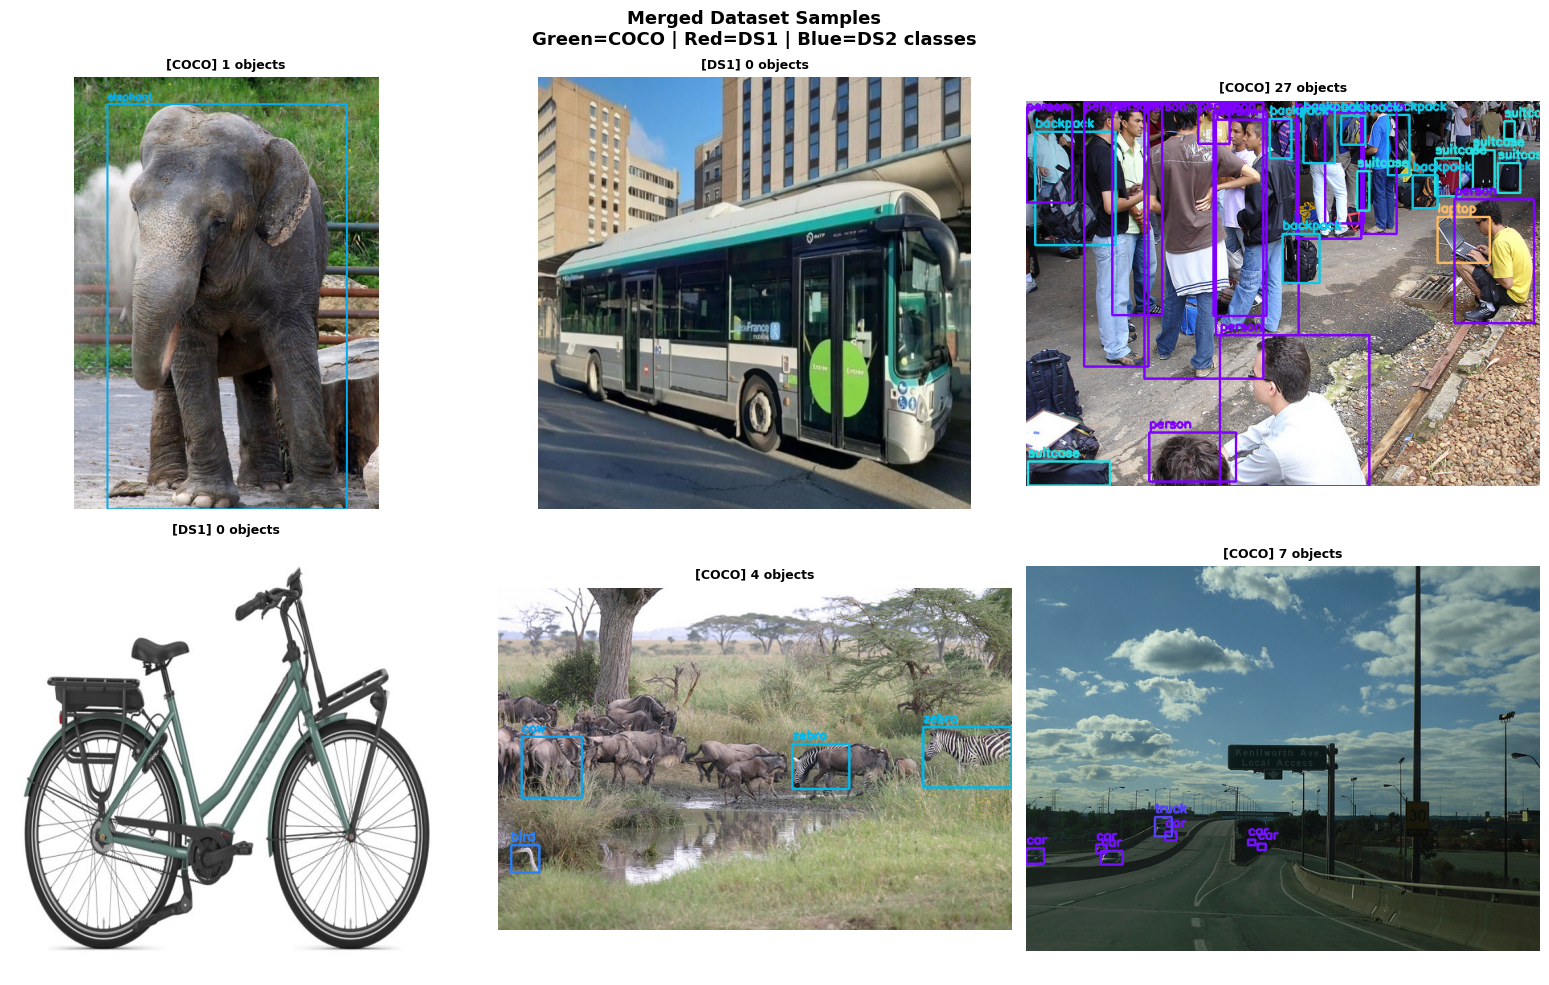

In [46]:
# ══════════════════════════════════════════════════════════
# CELL 3g: VERIFY MERGED DATASET
# ══════════════════════════════════════════════════════════
import os
import yaml
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path('/kaggle/working/merged_dataset')
YAML_PATH  = MERGED_DIR / 'data.yaml'

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

print("=" * 60)
print("MERGED DATASET VERIFICATION")
print("=" * 60)
print(f"Total classes: {cfg['nc']}")
print()

# ── Count images and labels per split ─────────────────────
total_imgs = 0
total_lbls = 0
for split in ['train', 'val']:
    img_dir = MERGED_DIR / 'images' / split
    lbl_dir = MERGED_DIR / 'labels' / split

    imgs = len(list(img_dir.glob('*'))) \
           if img_dir.exists() else 0
    lbls = len(list(lbl_dir.glob('*.txt'))) \
           if lbl_dir.exists() else 0

    total_imgs += imgs
    total_lbls += lbls
    match  = "✓" if imgs == lbls else "⚠"
    prefix = "coco:"
    coco_c  = len([f for f in img_dir.glob('*')
                    if f.name.startswith('coco_')]) \
               if img_dir.exists() else 0
    ds1_c   = len([f for f in img_dir.glob('*')
                    if f.name.startswith('ds1_')]) \
               if img_dir.exists() else 0
    ds2_c   = len([f for f in img_dir.glob('*')
                    if f.name.startswith('ds2_')]) \
               if img_dir.exists() else 0

    print(f"  {match} {split:8s}: {imgs:5d} images | "
          f"{lbls:5d} labels")
    print(f"         ├── COCO:      {coco_c:5d}")
    print(f"         ├── Dataset1:  {ds1_c:5d}")
    print(f"         └── Dataset2:  {ds2_c:5d}")

print(f"\n  Total: {total_imgs:5d} images | "
      f"{total_lbls:5d} labels")

# ── Count class distribution ──────────────────────────────
print("\nClass distribution (from labels):")
print("-" * 60)

class_counts = defaultdict(int)
lbl_dir      = MERGED_DIR / 'labels' / 'train'

for lbl_file in list(lbl_dir.glob('*.txt'))[:5000]:
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                class_counts[cls_id] += 1

# Show counts for new classes (80+) and top COCO classes
print("\n  New classes (80+):")
for i, cls in enumerate(TRULY_NEW_CLASSES):
    count = class_counts.get(80+i, 0)
    bar   = "█" * min(count//10, 30)
    status = "✓" if count > 100 else \
             "~" if count > 50  else "✗"
    print(f"  {status} [{80+i:3d}] {cls:25s}: "
          f"{count:5d} {bar}")

print("\n  Top COCO classes found:")
coco_counts = {k:v for k,v in class_counts.items()
               if k < 80}
top_coco    = sorted(coco_counts.items(),
                      key=lambda x: x[1],
                      reverse=True)[:10]
for cls_id, count in top_coco:
    cls_name = COCO_CLASSES[cls_id]
    bar      = "█" * min(count//50, 30)
    print(f"     [{cls_id:3d}] {cls_name:25s}: "
          f"{count:5d} {bar}")

print(f"\n{'='*60}")
if total_imgs > 1000:
    print("✓ Dataset looks good!")
else:
    print("⚠ Low image count - check above for issues")

# ── Show sample images ────────────────────────────────────
def show_merged_samples(merged_dir, num=6):
    img_dir = Path(merged_dir) / 'images' / 'train'
    lbl_dir = Path(merged_dir) / 'labels' / 'train'

    all_imgs = list(img_dir.glob('*'))
    if not all_imgs:
        return

    samples = random.sample(all_imgs, min(num, len(all_imgs)))
    cmap    = plt.cm.rainbow(
        np.linspace(0, 1, max(NC_TOTAL, 1))
    )
    colors  = (cmap[:,:3]*255).astype(int)

    fig, axes = plt.subplots(2, 3, figsize=(16,10))
    axes      = axes.flatten()

    for idx, img_path in enumerate(samples):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        img      = cv2.imread(str(img_path))
        if img is None:
            continue
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        obj_count = 0

        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls_id      = int(parts[0])
                    cx,cy,bw,bh = map(float, parts[1:])
                    x1 = max(0, int((cx-bw/2)*w))
                    y1 = max(0, int((cy-bh/2)*h))
                    x2 = min(w, int((cx+bw/2)*w))
                    y2 = min(h, int((cy+bh/2)*h))

                    color = tuple(
                        colors[cls_id % len(colors)].tolist()
                    )
                    cv2.rectangle(img,(x1,y1),(x2,y2),
                                   color, 2)
                    label = ALL_CLASSES[cls_id] \
                            if cls_id < len(ALL_CLASSES) \
                            else str(cls_id)
                    cv2.putText(img, label,
                               (x1, max(y1-6,12)),
                               cv2.FONT_HERSHEY_SIMPLEX,
                               0.5, color, 2)
                    obj_count += 1

        # Source label from filename
        src = "COCO" if img_path.name.startswith("coco") \
              else "DS1" if img_path.name.startswith("ds1") \
              else "DS2"

        axes[idx].imshow(img)
        axes[idx].set_title(
            f"[{src}] {obj_count} objects",
            fontsize=9, fontweight='bold'
        )
        axes[idx].axis('off')

    plt.suptitle(
        'Merged Dataset Samples\n'
        'Green=COCO | Red=DS1 | Blue=DS2 classes',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('/kaggle/working/'
                'merged_samples.png',
                dpi=150, bbox_inches='tight')
    plt.show()

show_merged_samples(MERGED_DIR)


In [ ]:
from ultralytics import YOLO
import shutil
from pathlib import Path

BACKUP = Path('/kaggle/working/backups')
BACKUP.mkdir(exist_ok=True)


model = YOLO('yolov8n.pt')

results = model.train(
    data          = '/kaggle/working/merged_dataset/data.yaml',
    epochs        = 50,        
    imgsz         = 640,
    batch         = 16,
    freeze        = 10,        # to freeze only the backbone
    lr0           = 1e-4,      # ← was 5e-4, lower to avoid overfitting
    lrf           = 0.01,
    warmup_epochs = 3,
    patience      = 15,
    
    # ── Augmentation to improve generalization ──────────────────────────
    hsv_h         = 0.015,     # hue augmentation
    hsv_s         = 0.7,       # saturation augmentation
    hsv_v         = 0.4,       # brightness augmentation
    degrees       = 10.0,      # random rotation
    translate     = 0.1,       # random translation
    scale         = 0.5,       # random scale
    flipud        = 0.1,       # vertical flip
    fliplr        = 0.5,       # horizontal flip
    mosaic        = 1.0,       # mosaic augmentation 
    mixup         = 0.1,       # mixup augmentation
    copy_paste    = 0.1,       # copy-paste augmentation

    device        = 0,
    project       = '/kaggle/working/yolo_blind_assist',
    name          = 'run_generalized',
    save          = True,
    save_period   = 1,
    plots         = True,
    val           = True,
)

Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/merged_dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run_generalized, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [ ]:
# ── Cell 6: Validate on val set ───────────────────────────────────────────
metrics = model.val()

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

In [ ]:
from pathlib import Path

MERGED = Path('/kaggle/working/merged_dataset')

train_imgs = list((MERGED / 'images' / 'train').glob('*'))
val_imgs   = list((MERGED / 'images' / 'val').glob('*'))

print(f"Training images:   {len(train_imgs)}")
print(f"Validation images: {len(val_imgs)}")       # 1008
print(f"Total:             {len(train_imgs) + len(val_imgs)}")